# Walk-forward conditioner workbench

This notebook visualizes one completed generic conditioner screen. It does not
select a winning hypothesis automatically. Every fit, cut point, and test result
comes from chronological folds recorded in the run manifest.

## Manual controls

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')

RESULT_ROOT = Path('/Users/petermillington/research/market-impact-research/alpha-search/experiments/current_sandbox_tool_demo/conditioner_results')
BAR_SIZE = 200
HORIZON_MINUTES = 10
SIDE = 'sell'
CONDITIONER = 'impact_residual'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})

## Load the frozen run

In [2]:
manifest = json.loads((RESULT_ROOT / 'run_manifest.json').read_text())
fits = pl.read_csv(RESULT_ROOT / 'impact_fits.csv')
signals = pl.read_csv(RESULT_ROOT / 'fold_signal_summary.csv')
increments = pl.read_csv(RESULT_ROOT / 'fold_conditioner_increment.csv')
grid = pl.read_csv(RESULT_ROOT / 'fold_conditioning_grid.csv')
cuts = pl.read_csv(RESULT_ROOT / 'fold_feature_cuts.csv')
aggregate_increments = pl.read_csv(RESULT_ROOT / 'aggregate_conditioner_increment.csv')

display({
    'data_fingerprint': manifest['data_fingerprint'],
    'event_bar_sizes': manifest['event_bar_sizes'],
    'clock_horizons_minutes': manifest['clock_horizons_minutes'],
    'primary_feature': manifest['primary_feature'],
    'conditioners': manifest['conditioners'],
    'folds': len(manifest['folds']),
})
display(pl.DataFrame(manifest['folds']))

{'data_fingerprint': 'cf5c42aeef099ae3b15b777bf64cdb0ba42a599ce0feb67200c3deee748dd832',
 'event_bar_sizes': [200, 500, 1000],
 'clock_horizons_minutes': [10, 15],
 'primary_feature': 'aligned_pretrend_12000_events',
 'conditioners': ['impact_residual',
  'normalised_range',
  'relative_flow_rate',
  'aligned_flow_persistence_12000_events',
  'fills_per_event',
  'price_levels_per_event'],
 'folds': 5}

fold,train_start,train_end,test_start,test_end,embargo_days
i64,str,str,str,str,i64
0,"""2019-09-01""","""2020-09-01""","""2020-09-01""","""2020-12-01""",1
1,"""2019-12-01""","""2020-12-01""","""2020-12-01""","""2021-03-01""",1
2,"""2020-03-01""","""2021-03-01""","""2021-03-01""","""2021-06-01""",1
3,"""2020-06-01""","""2021-06-01""","""2021-06-01""","""2021-09-01""",1
4,"""2020-09-01""","""2021-09-01""","""2021-09-01""","""2021-12-01""",1


## Impact-fit drift across folds

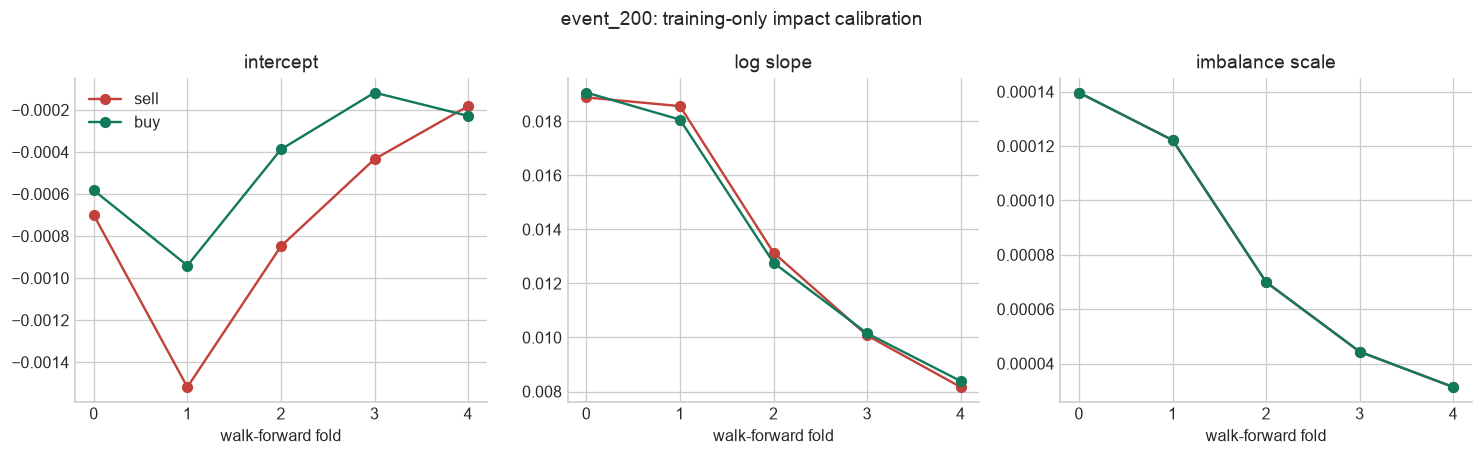

In [3]:
part = fits.filter(pl.col('construction') == f'event_{BAR_SIZE}').sort('fold')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for side, colour in [('sell', '#c2413b'), ('buy', '#13795b')]:
    chosen = part.filter(pl.col('side') == side)
    axes[0].plot(chosen['fold'], chosen['intercept'], marker='o', color=colour, label=side)
    axes[1].plot(chosen['fold'], chosen['slope'], marker='o', color=colour)
    axes[2].plot(chosen['fold'], chosen['imbalance_scale'], marker='o', color=colour)
for ax, title in zip(axes, ['intercept', 'log slope', 'imbalance scale']):
    ax.set_title(title)
    ax.set_xlabel('walk-forward fold')
axes[0].legend()
fig.suptitle(f'event_{BAR_SIZE}: training-only impact calibration')
plt.tight_layout()
plt.show()

## Training cut-point drift

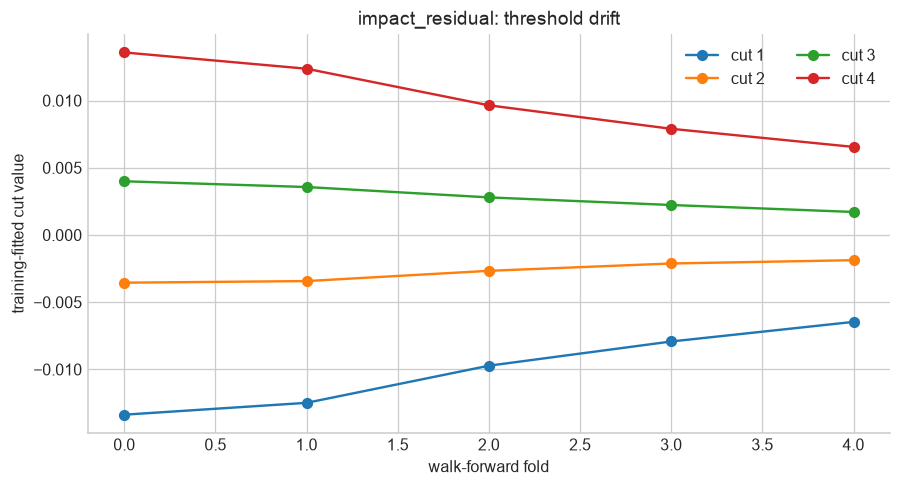

In [4]:
part = cuts.filter(
    (pl.col('construction') == f'event_{BAR_SIZE}') &
    (pl.col('feature') == CONDITIONER) &
    (pl.col('side') == (-1 if SIDE == 'sell' else 1))
).sort('fold', 'cut_number')
fig, ax = plt.subplots(figsize=(9, 4.5))
for cut_number in sorted(part['cut_number'].unique().to_list()):
    chosen = part.filter(pl.col('cut_number') == cut_number)
    ax.plot(chosen['fold'], chosen['cut_value'], marker='o', label=f'cut {cut_number}')
ax.set_xlabel('walk-forward fold')
ax.set_ylabel('training-fitted cut value')
ax.set_title(f'{CONDITIONER}: threshold drift')
ax.legend(ncol=2)
plt.show()

## Plain and conditioned rule by test fold

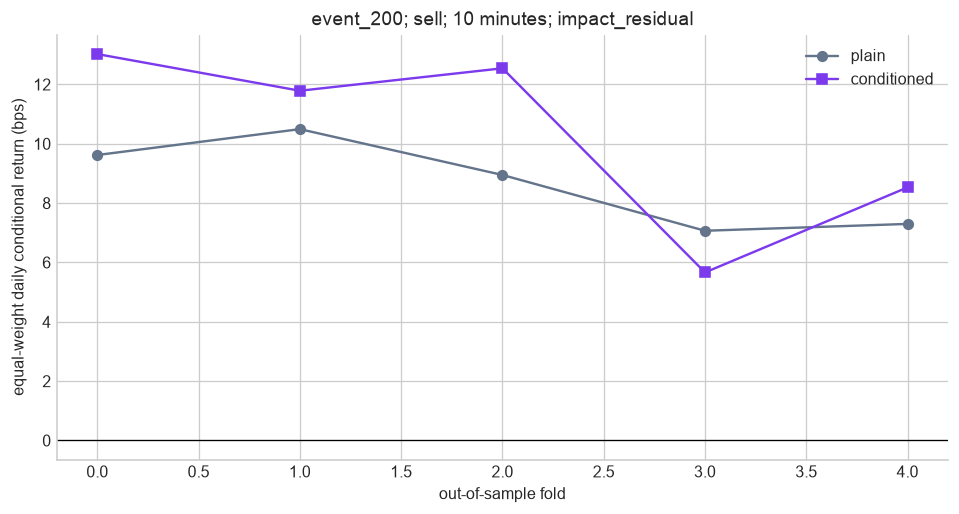

fold,test_start,test_end,strategy,signal_rate,day_mean_bps,day_t_stat
i64,str,str,str,f64,f64,f64
0,"""2020-09-01""","""2020-12-01""","""primary_reversion_q_high""",0.148306,9.621252,8.69374
0,"""2020-09-01""","""2020-12-01""","""primary_reversion_conditioner_…",0.026436,13.023014,7.575675
1,"""2020-12-01""","""2021-03-01""","""primary_reversion_q_high""",0.252603,10.493335,9.791009
1,"""2020-12-01""","""2021-03-01""","""primary_reversion_conditioner_…",0.029855,11.787391,7.963733
2,"""2021-03-01""","""2021-06-01""","""primary_reversion_q_high""",0.163088,8.948224,6.65717
2,"""2021-03-01""","""2021-06-01""","""primary_reversion_conditioner_…",0.017955,12.543832,4.93083
3,"""2021-06-01""","""2021-09-01""","""primary_reversion_q_high""",0.089456,7.068054,6.933071
3,"""2021-06-01""","""2021-09-01""","""primary_reversion_conditioner_…",0.010487,5.663523,1.70019
4,"""2021-09-01""","""2021-12-01""","""primary_reversion_q_high""",0.139047,7.298601,6.245584


In [5]:
part = signals.filter(
    (pl.col('construction') == f'event_{BAR_SIZE}') &
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    (pl.col('side') == SIDE) &
    (pl.col('conditioner') == CONDITIONER)
).sort('fold')
fig, ax = plt.subplots(figsize=(10, 4.8))
for strategy, colour, marker in [
    ('primary_reversion_q_high', '#64748b', 'o'),
    ('primary_reversion_conditioner_q_high', '#7c3aed', 's'),
]:
    chosen = part.filter(pl.col('strategy') == strategy)
    ax.plot(chosen['fold'], chosen['day_mean_bps'], marker=marker, color=colour,
            label=('conditioned' if 'conditioner' in strategy else 'plain'))
ax.axhline(0, color='black', lw=.8)
ax.set_xlabel('out-of-sample fold')
ax.set_ylabel('equal-weight daily conditional return (bps)')
ax.set_title(f'event_{BAR_SIZE}; {SIDE}; {HORIZON_MINUTES} minutes; {CONDITIONER}')
ax.legend()
plt.show()
display(part.select('fold', 'test_start', 'test_end', 'strategy', 'signal_rate',
                    'day_mean_bps', 'day_t_stat'))

## Conditioner comparison across folds

construction,horizon_minutes,side,primary_feature,conditioner,comparison,folds,mean_day_mean_difference_bps,median_day_mean_difference_bps,minimum_day_mean_difference_bps,positive_fold_share
str,i64,str,str,str,str,i64,f64,f64,f64,f64
"""event_200""",10,"""sell""","""aligned_pretrend_12000_events""","""aligned_flow_persistence_12000…","""high_conditioner_minus_uncondi…",5,1.248725,1.040206,0.566523,1.0
"""event_200""",10,"""sell""","""aligned_pretrend_12000_events""","""impact_residual""","""high_conditioner_minus_uncondi…",5,1.63373,1.294055,-1.404531,0.8
"""event_200""",10,"""sell""","""aligned_pretrend_12000_events""","""fills_per_event""","""high_conditioner_minus_uncondi…",5,1.777609,1.68593,1.216518,1.0
"""event_200""",10,"""sell""","""aligned_pretrend_12000_events""","""price_levels_per_event""","""high_conditioner_minus_uncondi…",5,3.408621,3.689579,2.648921,1.0
"""event_200""",10,"""sell""","""aligned_pretrend_12000_events""","""relative_flow_rate""","""high_conditioner_minus_uncondi…",5,6.232608,6.002383,3.166151,1.0
"""event_200""",10,"""sell""","""aligned_pretrend_12000_events""","""normalised_range""","""high_conditioner_minus_uncondi…",5,10.811921,11.392312,2.260784,1.0


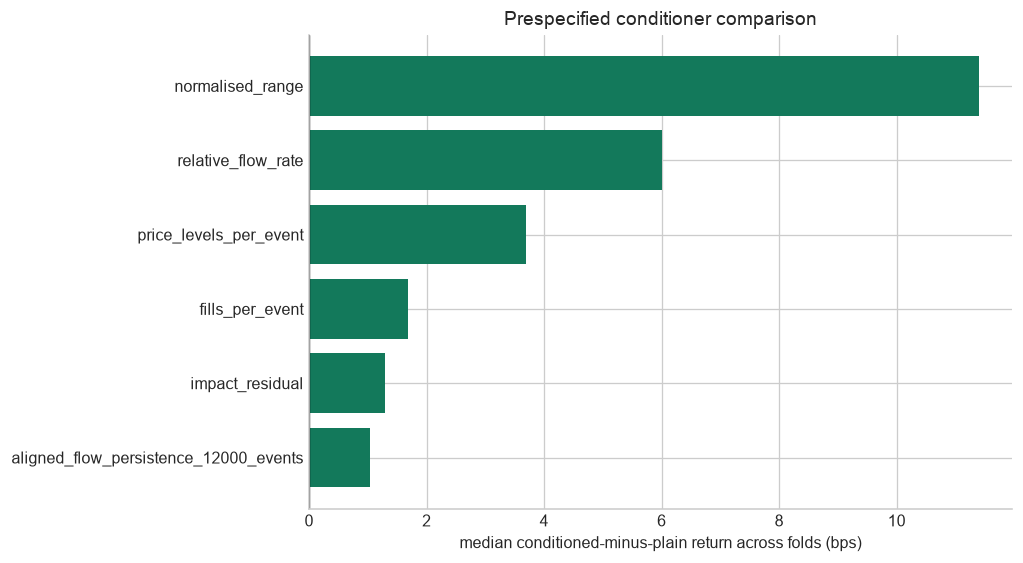

In [6]:
summary = aggregate_increments.filter(
    (pl.col('construction') == f'event_{BAR_SIZE}') &
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    (pl.col('side') == SIDE) &
    (pl.col('comparison') == 'high_conditioner_minus_unconditioned')
).sort('median_day_mean_difference_bps')
display(summary)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(summary['conditioner'], summary['median_day_mean_difference_bps'],
        color=np.where(summary['median_day_mean_difference_bps'].to_numpy() >= 0,
                       '#13795b', '#c2413b'))
ax.axvline(0, color='black', lw=.8)
ax.set_xlabel('median conditioned-minus-plain return across folds (bps)')
ax.set_title('Prespecified conditioner comparison')
plt.tight_layout()
plt.show()

## Selected fold surfaces

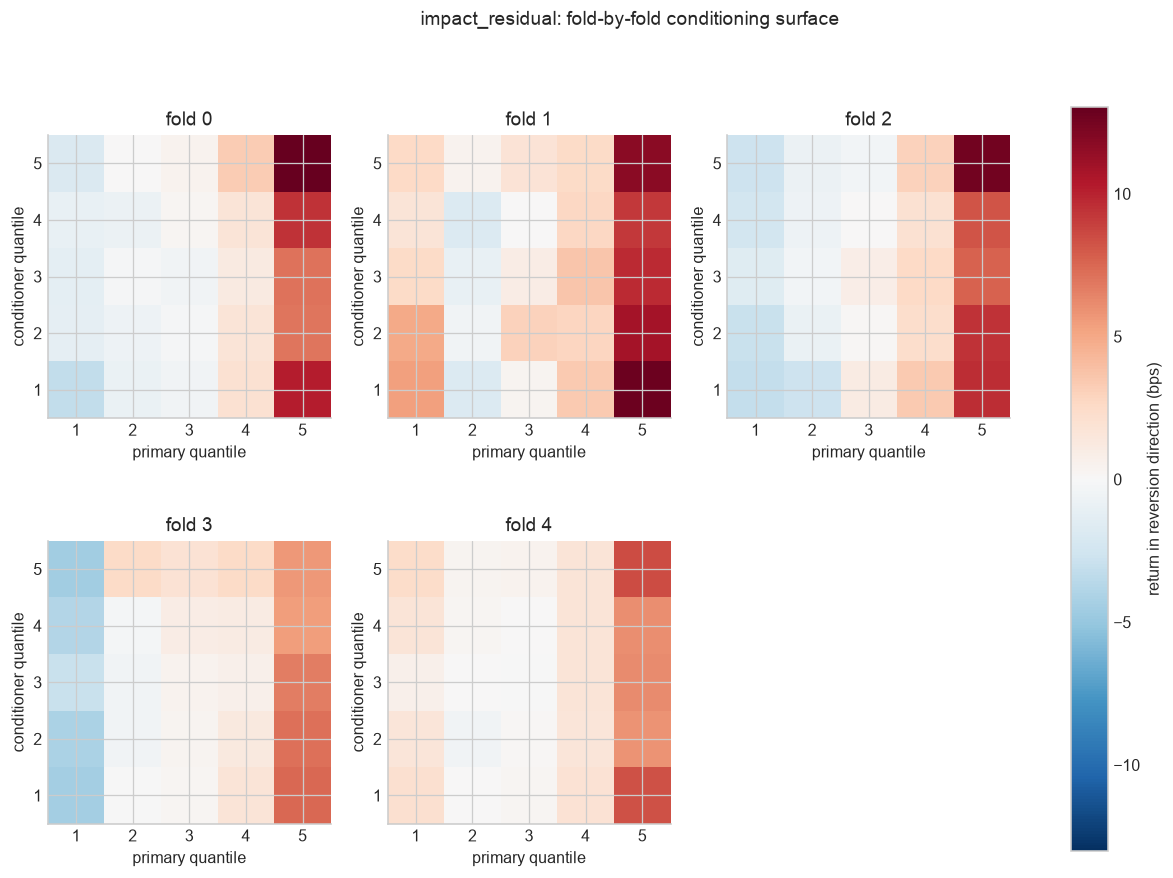

In [7]:
folds = sorted(grid['fold'].unique().to_list())
columns = min(3, len(folds))
rows = int(np.ceil(len(folds) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(4.5 * columns, 4.2 * rows), squeeze=False)
matrices = []
for fold in folds:
    chosen = grid.filter(
        (pl.col('construction') == f'event_{BAR_SIZE}') &
        (pl.col('horizon_minutes') == HORIZON_MINUTES) &
        (pl.col('side') == SIDE) &
        (pl.col('conditioner') == CONDITIONER) &
        (pl.col('fold') == fold)
    )
    matrix = np.full((5, 5), np.nan)
    for row in chosen.iter_rows(named=True):
        matrix[row['conditioner_quantile'] - 1, row['primary_quantile'] - 1] = row['day_mean_bps']
    matrices.append(matrix)
limit = max(float(np.nanmax(np.abs(matrix))) for matrix in matrices)
for ax, fold, matrix in zip(axes.flat, folds, matrices):
    image = ax.imshow(matrix, origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit)
    ax.set_title(f'fold {fold}')
    ax.set_xlabel('primary quantile')
    ax.set_ylabel('conditioner quantile')
    ax.set_xticks(range(5), range(1, 6))
    ax.set_yticks(range(5), range(1, 6))
for ax in axes.flat[len(folds):]:
    ax.axis('off')
fig.colorbar(image, ax=axes, label='return in reversion direction (bps)')
fig.suptitle(f'{CONDITIONER}: fold-by-fold conditioning surface')
plt.show()

## Interpretation discipline

- Treat nearby event-bar sizes and horizons as correlated robustness checks, not independent discoveries.
- Inspect threshold drift and signal frequency before interpreting return differences.
- Do not promote a conditioner on pooled means alone; require directionally consistent chronological folds.
- Profitability, overlap, execution costs and position sizing remain a separate stage after a rule is frozen.